iter 403: stagnated → injected noise, loss=0.000433
iter 503: stagnated → injected noise, loss=0.000433
iter 603: stagnated → injected noise, loss=0.000433
iter 703: stagnated → injected noise, loss=0.000433
iter 803: stagnated → injected noise, loss=0.000433
iter 903: stagnated → injected noise, loss=0.000433
Initial L2 discrepancy: 0.043237260509622316
Best L2 discrepancy value: 0.02086297538360914


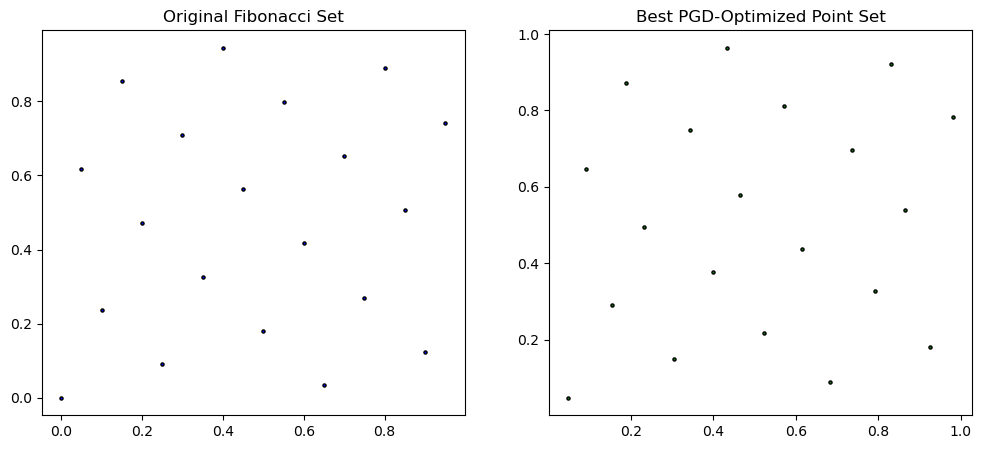

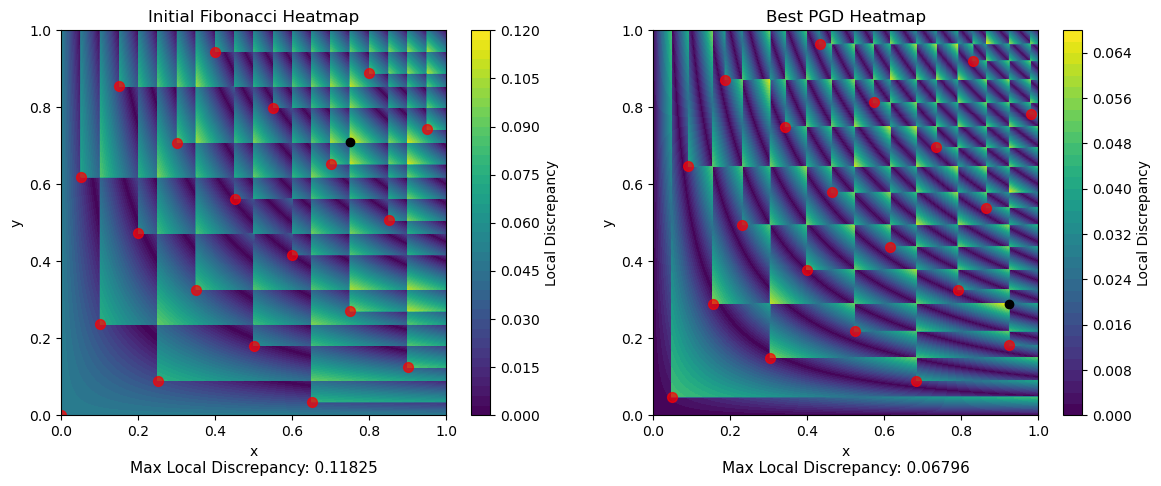

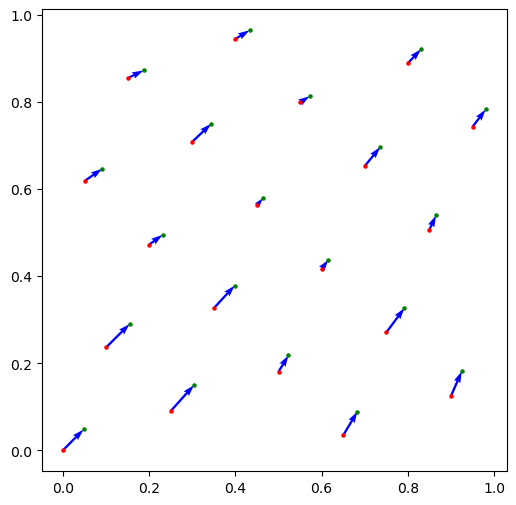

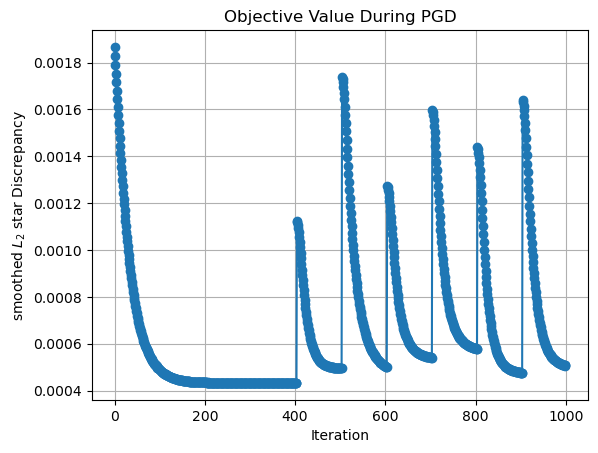

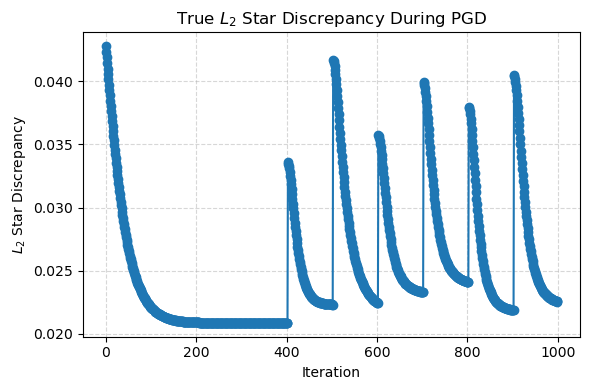

Optimal L2‐star discrepancy achieved: 0.020862


In [69]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 20

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 5e-4
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 1000
patience   = 100
flat_eps   = 1e-8
noise_scale= 0.05

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black', s=small_size)
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black', s=small_size)
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial', s=small_size)
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best', s=small_size)

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

iter 133: stagnated → injected noise, loss=0.000002
iter 233: stagnated → injected noise, loss=0.000002
iter 333: stagnated → injected noise, loss=0.000002
iter 433: stagnated → injected noise, loss=0.000002
iter 533: stagnated → injected noise, loss=0.000002
iter 633: stagnated → injected noise, loss=0.000002
iter 733: stagnated → injected noise, loss=0.000002
iter 833: stagnated → injected noise, loss=0.000002
iter 933: stagnated → injected noise, loss=0.000002
Initial L2 discrepancy: 0.0030635360667779876
Best L2 discrepancy value: 0.001660637155054754


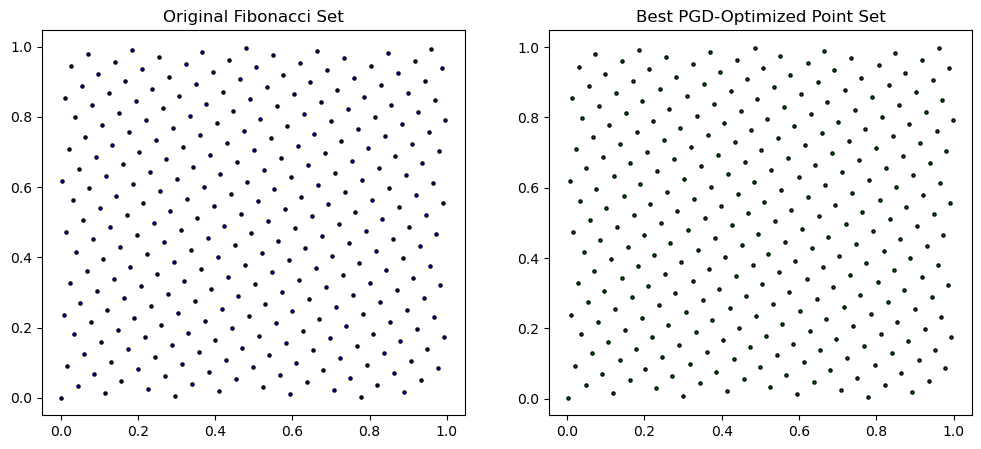

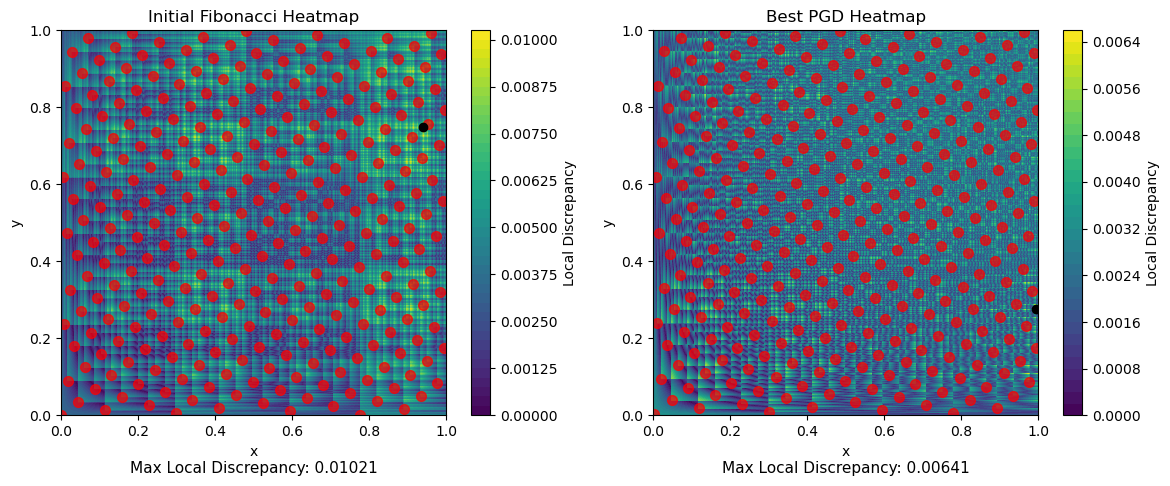

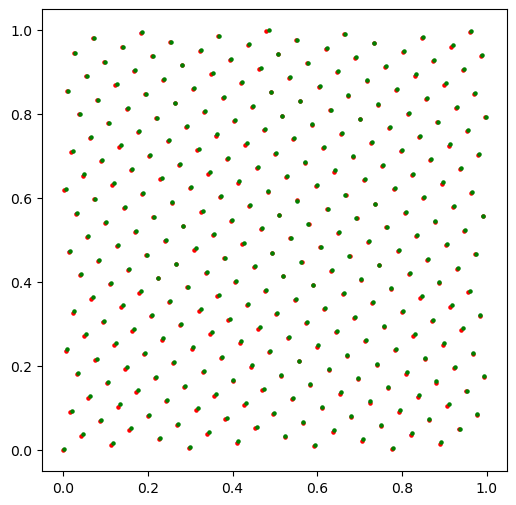

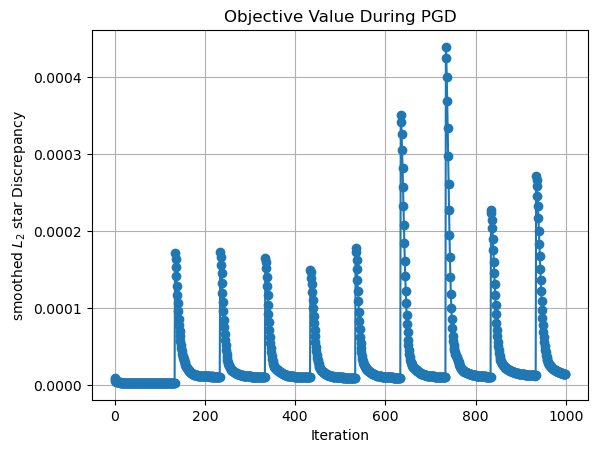

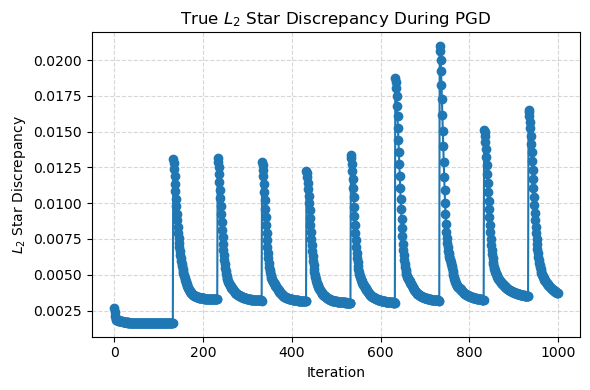

Optimal L2‐star discrepancy achieved: 0.001638


In [73]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 300

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 5e-4
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 1000
patience   = 100
flat_eps   = 1e-7
noise_scale= 0.1

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black', s=small_size)
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black', s=small_size)
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial', s=small_size)
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best', s=small_size)

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

Initial L2 discrepancy: 0.0009414968051797866
Best L2 discrepancy value: 0.0009414968051797866


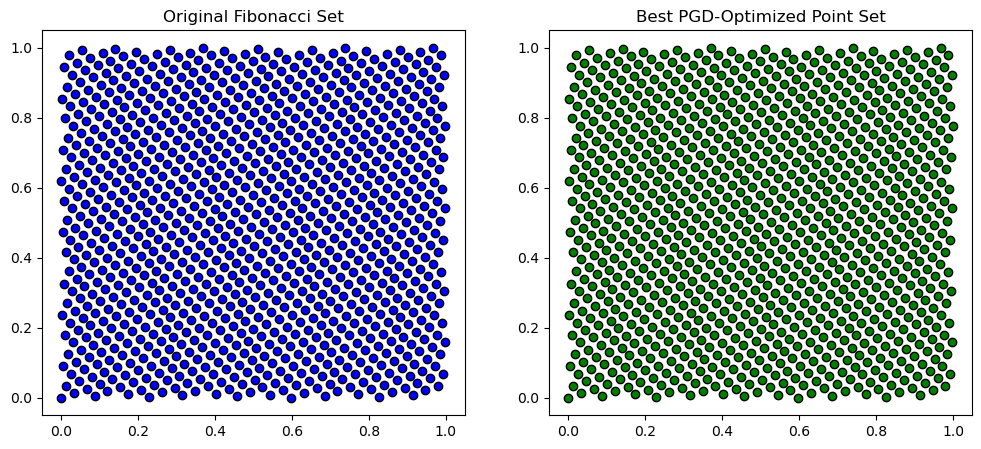

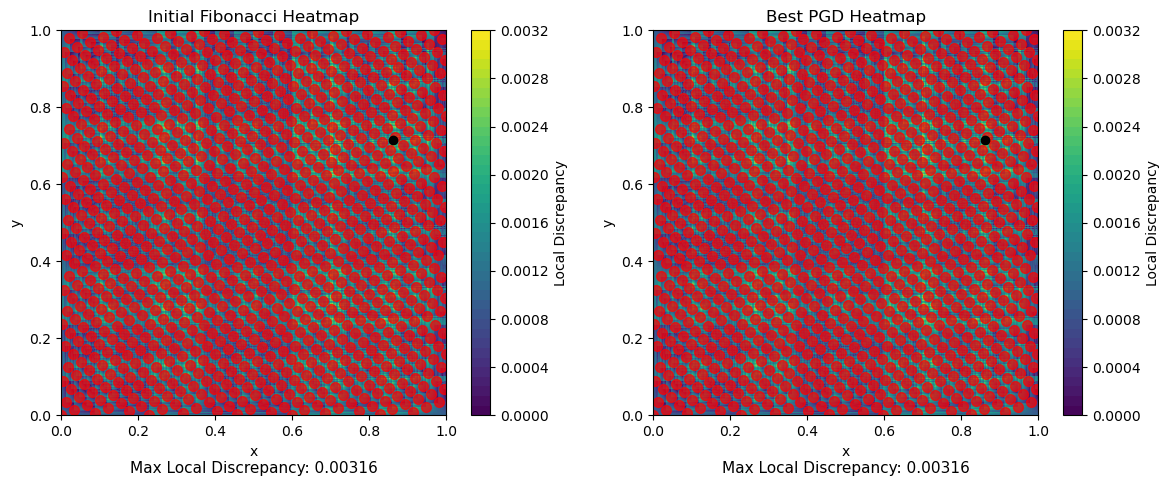

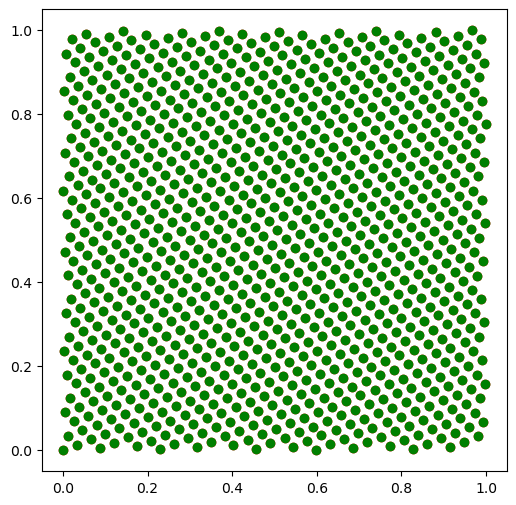

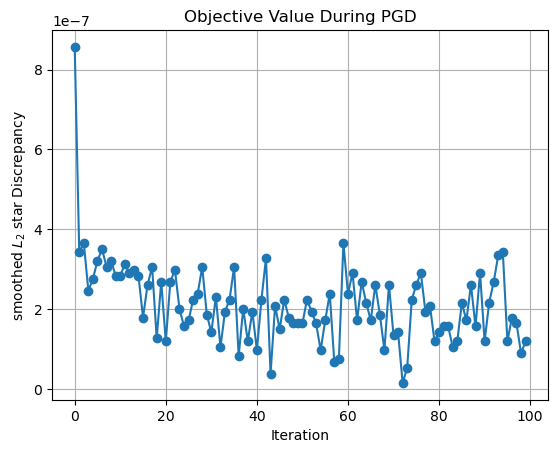

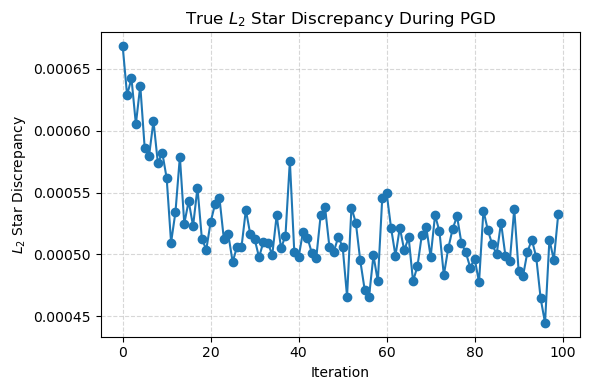

Optimal L2‐star discrepancy achieved: 0.000445


In [53]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 1020

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 5e-4
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 100
patience   = 500
flat_eps   = 1e-6
noise_scale= 0.01

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial')
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best')

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

Initial L2 discrepancy: 0.001313990036505277
Best L2 discrepancy value: 0.0009118924588931715


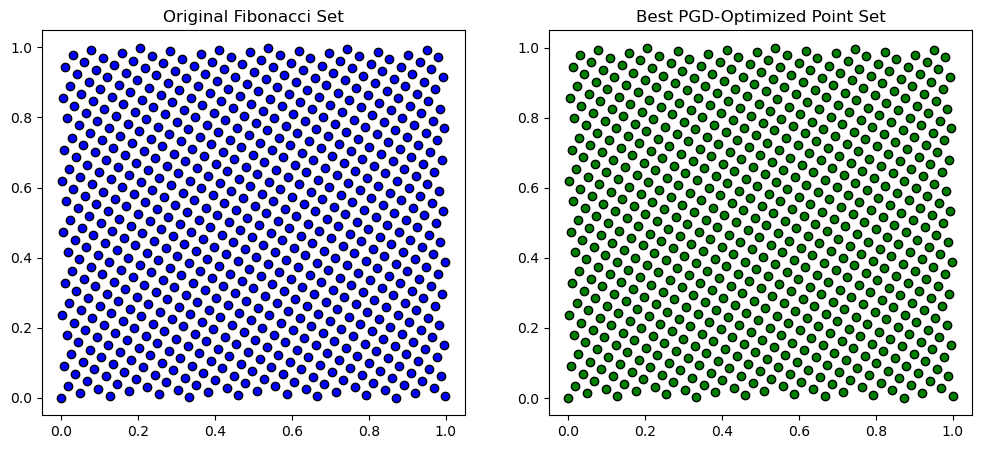

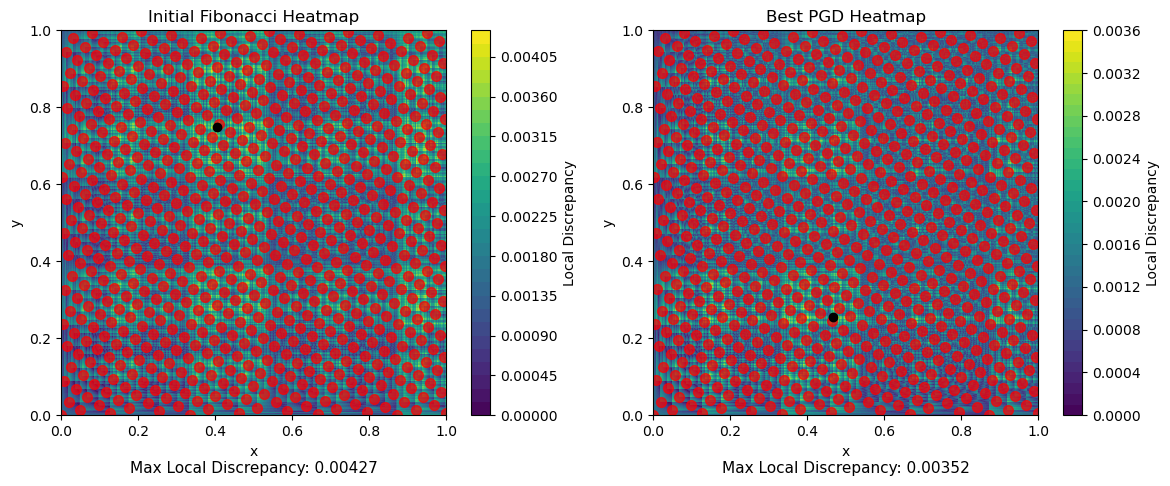

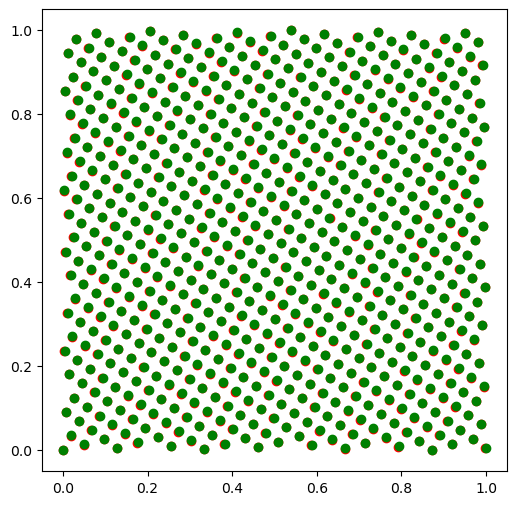

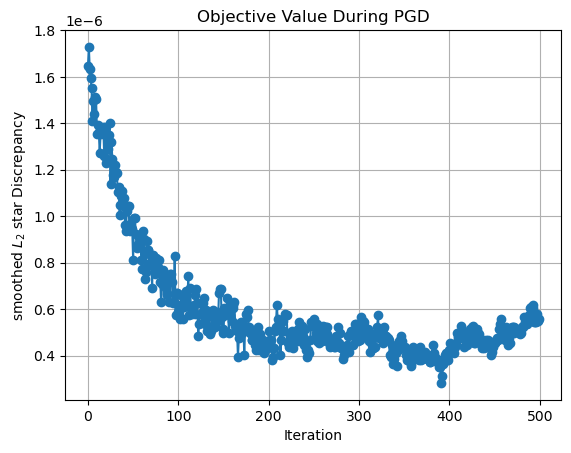

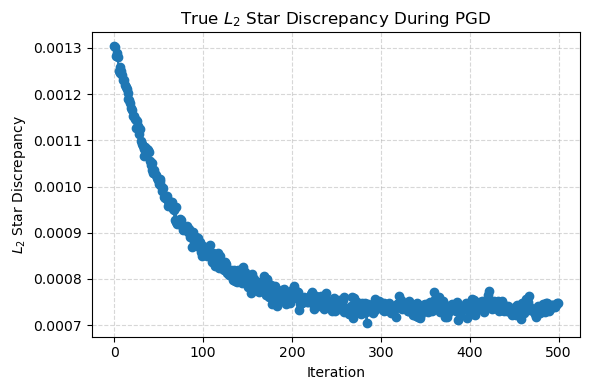

Optimal L2‐star discrepancy achieved: 0.000705


In [61]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 700

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 3e-5
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 500
patience   = 1000
flat_eps   = 1e-6
noise_scale= 0.01

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial')
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best')

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

Initial L2 discrepancy: 0.0006638409447416957
Best L2 discrepancy value: 0.0006638409447416957


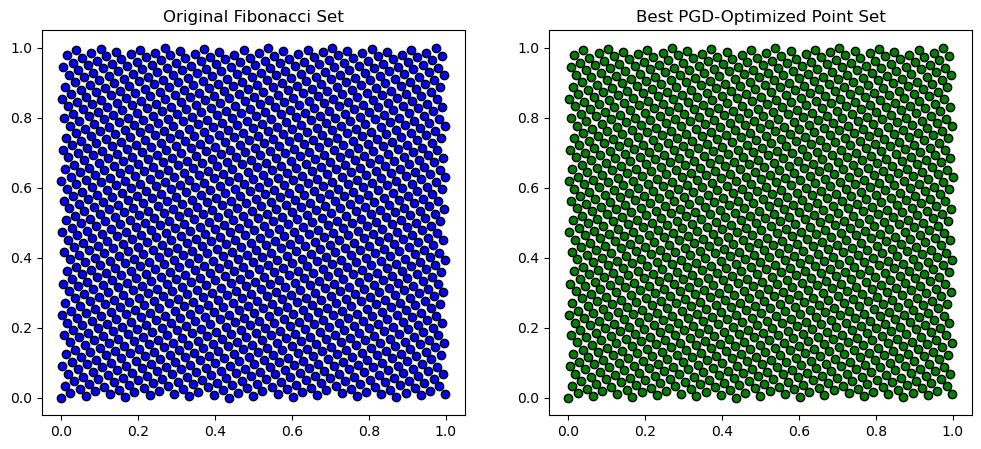

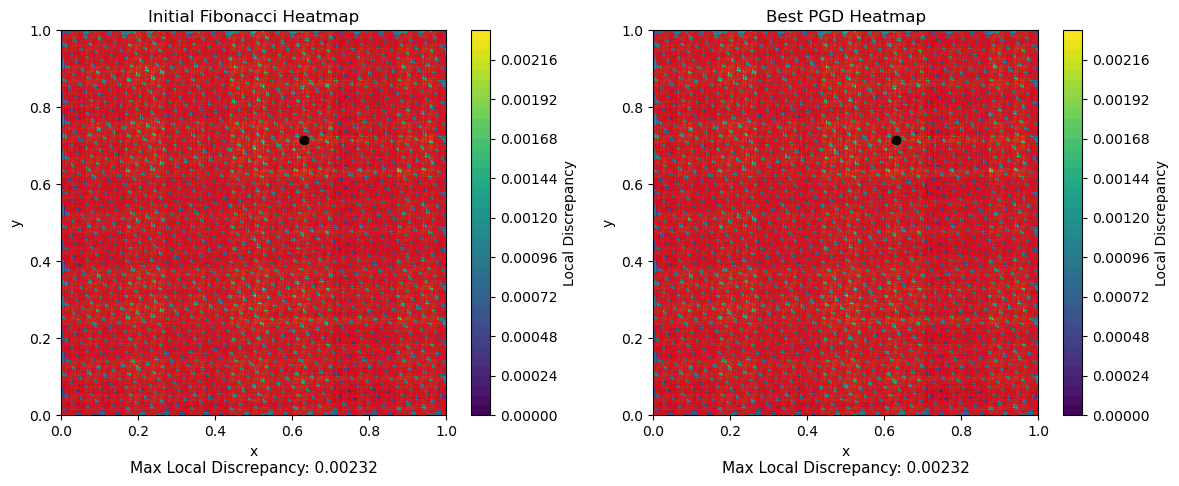

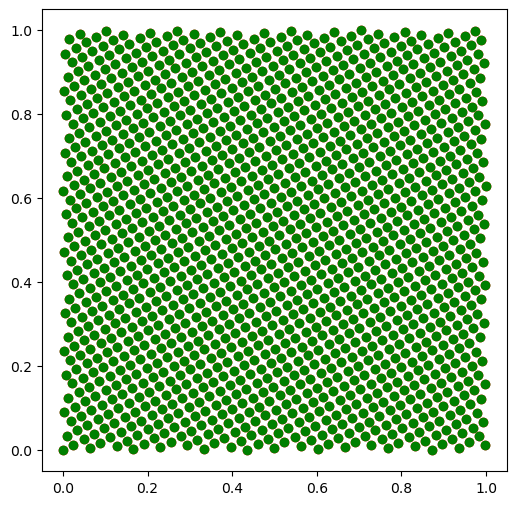

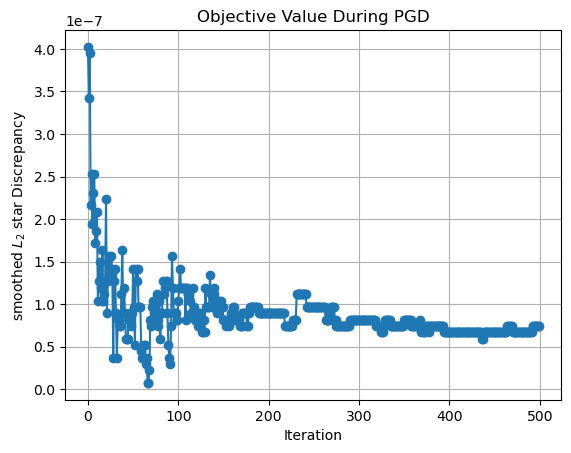

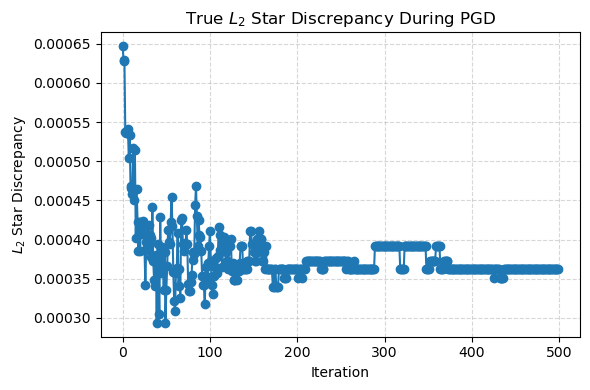

Optimal L2‐star discrepancy achieved: 0.000294


In [76]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 1400

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 3e-5
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 500
patience   = 1000
flat_eps   = 1e-6
noise_scale= 0.01

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial')
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best')

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

PGD @ N=20… 2.08629e-02
PGD @ N=60… 7.61120e-03
PGD @ N=100… 4.68820e-03
PGD @ N=140… 3.38158e-03
PGD @ N=180… 2.71128e-03
PGD @ N=220… 2.22708e-03
PGD @ N=260… 1.89736e-03
PGD @ N=300… 1.65062e-03
PGD @ N=340… 1.45067e-03
PGD @ N=380… 1.31125e-03
PGD @ N=420… 1.20262e-03
PGD @ N=460… 1.10654e-03
PGD @ N=500… 1.01720e-03
PGD @ N=540… 9.47379e-04
PGD @ N=580… 8.95426e-04
PGD @ N=620… 8.29976e-04
PGD @ N=660… 7.60898e-04
PGD @ N=700… 7.39458e-04
PGD @ N=740… 6.91232e-04
PGD @ N=780… 6.51735e-04
PGD @ N=820… 6.02677e-04
PGD @ N=860… 5.72175e-04
PGD @ N=900… 5.51061e-04
PGD @ N=940… 5.57723e-04
PGD @ N=980… 5.26356e-04
PGD @ N=1020… 4.76973e-04


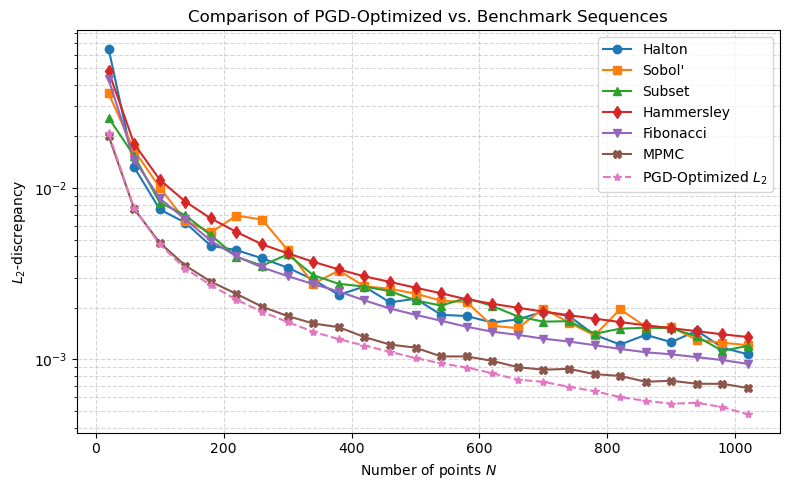

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# -----------------------------------------------------------------------------
# 1) The list of N values
# -----------------------------------------------------------------------------
N_list = np.array([
    20,  60, 100, 140, 180, 220, 260, 300, 340, 380, 420, 460, 500,
    540, 580, 620, 660, 700, 740, 780, 820, 860, 900, 940, 980, 1020
])

# -----------------------------------------------------------------------------
# 2) Benchmark L2-discrepancies from Table 4
# -----------------------------------------------------------------------------
halton      = np.array([
  0.06511,0.01323,0.00751,0.00627,0.00460,0.00434,0.00389,0.00343,
  0.00292,0.00238,0.00266,0.00215,0.00226,
  0.00182,0.00179,0.00164,0.00171,0.00190,0.00179,0.00139,0.00122,
  0.00139,0.00126,0.00147,0.00117,0.00107
])
sobol       = np.array([
  0.03564,0.01660,0.01006,0.00645,0.00551,0.00690,0.00655,0.00435,
  0.00276,0.00330,0.00267,0.00258,0.00242,
  0.00220,0.00216,0.00157,0.00152,0.00198,0.00164,0.00138,0.00196,
  0.00155,0.00154,0.00130,0.00125,0.00121
])
subset_sel  = np.array([
  0.02569,0.01541,0.00823,0.00693,0.00530,0.00397,0.00352,0.00410,
  0.00310,0.00276,0.00266,0.00250,0.00221,
  0.00206,0.00228,0.00205,0.00178,0.00166,0.00167,0.00141,0.00151,
  0.00153,0.00152,0.00136,0.00112,0.00120
])
hammersley  = np.array([
  0.04796,0.01812,0.01119,0.00833,0.00664,0.00554,0.00469,0.00416,
  0.00371,0.00335,0.00305,0.00283,0.00262,
  0.00243,0.00224,0.00211,0.00200,0.00190,0.00181,0.00173,0.00165,
  0.00158,0.00152,0.00146,0.00140,0.00135
])
fibonacci   = np.array([
  0.04324,0.01465,0.00870,0.00657,0.00492,0.00399,0.00344,0.00306,
  0.00275,0.00249,0.00221,0.00198,0.00182,
  0.00168,0.00155,0.00145,0.00139,0.00132,0.00127,0.00121,0.00115,
  0.00110,0.00107,0.00103,0.00099,0.00094
])
mpmc        = np.array([
  0.02016,0.00756,0.00479,0.00353,0.00284,0.00241,0.00203,0.00179,
  0.00162,0.00154,0.00135,0.00122,0.00117,
  0.00104,0.00104,0.00098,0.00090,0.00087,0.00088,0.00082,0.00080,
  0.00074,0.00075,0.00072,0.00072,0.00068
])

# -----------------------------------------------------------------------------
# 3) The PGD machinery (exactly as before)
# -----------------------------------------------------------------------------
def fibonacci_lattice(n):
    phi = (jnp.sqrt(5.) - 1.) / 2.
    i   = jnp.arange(n)
    return jnp.stack([ i/n, (i*phi) % 1. ], axis=1)

def softmax(a, b, tau=1e-8):
    return 0.5 * (a + b + jnp.sqrt((a - b)**2 + tau))

def L2_smoothed(P, tau=1e-8):
    n = P.shape[0]
    a = jnp.sum((1 - P[:,0]**2)*(1 - P[:,1]**2))/(2*n)
    xi, xj = jnp.meshgrid(P[:,0], P[:,0], indexing='ij')
    yi, yj = jnp.meshgrid(P[:,1], P[:,1], indexing='ij')
    b = jnp.sum((1 - softmax(xi,xj,tau))*(1 - softmax(yi,yj,tau)))/(n**2)
    return 1/9 - a + b

def optimize_pgd(n, num_iters=300, lr=5e-4):
    P = fibonacci_lattice(n)
    opt = optax.adam(lr)
    st  = opt.init(P)
    fvg = jax.jit(jax.value_and_grad(L2_smoothed))
    for _ in range(num_iters):
        loss, g = fvg(P)
        upds, st = opt.update(g, st)
        P = jnp.clip(optax.apply_updates(P, upds), 0.0, 1.0)
    return np.array(P)

def L2_discrepancy(P):
    N = P.shape[0]
    sum1 = np.prod(1 - P**2, axis=1).sum()
    pm   = np.maximum(P[:,None,:], P[None,:,:])     # (N,N,2)
    sum2 = np.prod(1 - pm, axis=2).sum()
    return np.sqrt(3.**-2 - (1/N)*2.**-1*sum1 + (1/N**2)*sum2)

# -----------------------------------------------------------------------------
# 4) Run the sweep, collect PGD‐L2
# -----------------------------------------------------------------------------
pgd_L2 = []
for n in N_list:
    print(f"PGD @ N={n}…", end=" ")
    Popt = optimize_pgd(int(n), num_iters=300, lr=5e-4)
    val  = L2_discrepancy(Popt)
    print(f"{val:.5e}")
    pgd_L2.append(val)
pgd_L2 = np.array(pgd_L2)

# -----------------------------------------------------------------------------
# 5) Final plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(N_list, halton,      marker='o', label='Halton')
plt.plot(N_list, sobol,       marker='s', label="Sobol'")
plt.plot(N_list, subset_sel,  marker='^', label='Subset')
plt.plot(N_list, hammersley,  marker='d', label='Hammersley')
plt.plot(N_list, fibonacci,   marker='v', label='Fibonacci')
plt.plot(N_list, mpmc,        marker='X', label='MPMC')

plt.plot(N_list, pgd_L2,      marker='*', linestyle='--', label='PGD-Optimized $L_2$')

plt.xscale('linear')
plt.yscale('log')
plt.xlabel(r'Number of points $N$')
plt.ylabel(r'$L_2$-discrepancy')
plt.title('Comparison of PGD-Optimized vs. Benchmark Sequences')
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
